# Projet Fil Rouge
### Transformation d'images réelles en style artistique Monet

## Objectif
Transformer des photos réelles (de `photo_jpg`) en œuvres d'art dans le style de Monet (de `monet_jpg`). Générer une animation fluide qui passe progressivement d'une photo réelle à son équivalent stylisé.

## Plan du Projet

### Étape 1 : Préparation des Données
- Télécharger et organiser le dataset.

#### Contenu à utiliser
- `monet_jpg` : Peintures de Monet (300 images)
- `photo_jpg` : Photos réelles (7028 images)

#### Organisation des données
- `monet_jpg/`
- `photo_jpg/`


In [1]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Sun Jan 12 22:00:28 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off | 00000000:00:04.0 Off |                    0 |
| N/A   43C    P0              50W / 400W |      2MiB / 40960MiB |      0%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

In [2]:
# ====================================
# 1. Installer les bibliothèques nécessaires
# ====================================
#!pip install tensorflow==2.9.1 keras==2.9.0 tensorflow-addons==0.17.0






In [3]:
# ====================================
# 2. Importer les bibliothèques nécessaires
# ====================================
import tensorflow as tf
import tensorflow_addons as tfa
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import os


In [4]:
# ====================================
# 3. Charger les données
# ====================================
# connection a google drive
from google.colab import drive
drive.mount('/content/drive')

# Chemins vers les données sur Google Drive
MONET_FILENAMES = tf.io.gfile.glob('/content/drive/MyDrive/monet_jpg/*.jpg')
PHOTO_FILENAMES = tf.io.gfile.glob('/content/drive/MyDrive/photo_jpg/*.jpg')

# Fonction pour décoder les images JPEG en tenseurs TensorFlow
def decode_image(image):
    image = tf.image.decode_jpeg(image, channels=3)  # Décoder en RGB
    image = tf.image.resize(image, [256, 256])      # Redimensionner à 256x256
    image = (image / 127.5) - 1                     # Normaliser entre -1 et 1
    return image

# Fonction pour lire les fichiers TFRecord
def read_tfrecord(example):
    tfrecord_format = {
        "image": tf.io.FixedLenFeature([], tf.string)
    }
    example = tf.io.parse_single_example(example, tfrecord_format)
    image = decode_image(example['image'])
    return image

# Charger les datasets de Monet et des photos
def load_dataset(filenames):
    dataset = tf.data.Dataset.from_tensor_slices(filenames)
    dataset = dataset.map(lambda x: decode_image(tf.io.read_file(x)), num_parallel_calls=tf.data.AUTOTUNE)
    return dataset.batch(1)

# Créer les datasets
monet_ds = load_dataset(MONET_FILENAMES)
photo_ds = load_dataset(PHOTO_FILENAMES)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


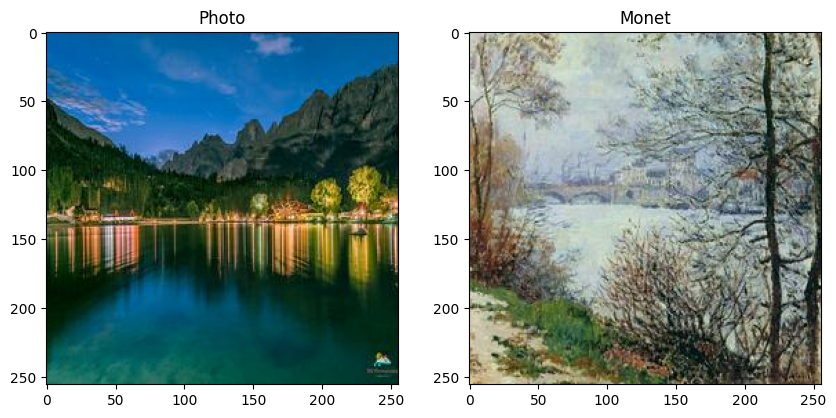

In [5]:

# ====================================
# 4. Visualiser un exemple d'image
# ====================================
example_monet = next(iter(monet_ds))
example_photo = next(iter(photo_ds))

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Photo")
plt.imshow((example_photo[0] + 1) / 2)  # Remettre entre 0 et 1 pour affichage
plt.subplot(1, 2, 2)
plt.title("Monet")
plt.imshow((example_monet[0] + 1) / 2)
plt.show()


In [19]:
# ====================================
# 5. Construire le générateur
# ====================================
import tensorflow as tf
from tensorflow.keras import layers
import tensorflow_addons as tfa

# Fonction pour construire une couche de "downsampling"
def downsample(filters, size, apply_instancenorm=True):
    """
    Crée un bloc de downsampling pour réduire la taille des images tout en augmentant la profondeur.
    Utilise des couches Conv2D suivies d'une normalisation et d'une activation.

    Args:
        filters (int): Nombre de filtres de convolution.
        size (int): Taille du noyau de convolution.
        apply_instancenorm (bool): Si True, applique une normalisation d'instance.

    Returns:
        tf.keras.Sequential: Un bloc de couches pour le downsampling.
    """
    initializer = tf.random_normal_initializer(0., 0.02)
    result = tf.keras.Sequential()
    result.add(layers.Conv2D(filters, size, strides=2, padding='same',
                             kernel_initializer=initializer, use_bias=False))
    if apply_instancenorm:
        result.add(tfa.layers.InstanceNormalization())
    result.add(layers.LeakyReLU())  # Ajoute une activation LeakyReLU pour éviter les gradients morts
    return result


# Fonction pour construire une couche de "upsampling"
def upsample(filters, size, apply_dropout=False):
    """
    Crée un bloc de upsampling pour augmenter la taille des images tout en réduisant la profondeur.
    Utilise des couches Conv2DTranspose suivies d'une normalisation et d'une activation.

    Args:
        filters (int): Nombre de filtres de convolution.
        size (int): Taille du noyau de convolution.
        apply_dropout (bool): Si True, applique un dropout pour éviter le surapprentissage.

    Returns:
        tf.keras.Sequential: Un bloc de couches pour le upsampling.
    """
    initializer = tf.random_normal_initializer(0., 0.02)
    result = tf.keras.Sequential()
    result.add(layers.Conv2DTranspose(filters, size, strides=2, padding='same',
                                       kernel_initializer=initializer, use_bias=False))
    result.add(tfa.layers.InstanceNormalization())
    if apply_dropout:
        result.add(layers.Dropout(0.5))  # Applique un dropout pour régulariser le modèle
    result.add(layers.ReLU())  # Ajoute une activation ReLU pour la non-linéarité
    return result


# Fonction pour construire le générateur complet
def Generator():
    """
    Construit le modèle générateur pour CycleGAN.
    Il utilise un encodeur-décodeur basé sur des blocs de downsampling et d'upsampling.

    Returns:
        tf.keras.Model: Le modèle complet du générateur.
    """
    print("Initialisation du générateur...")

    # Définir l'entrée
    inputs = layers.Input(shape=[256, 256, 3])  # Les images d'entrée ont une taille de 256x256 avec 3 canaux (RGB)
    print("Entrée créée avec succès.")

    # Bloc de downsampling (encodeur)
    try:
        down_stack = [
            downsample(64, 4, apply_instancenorm=False),  # La première couche n'a pas de normalisation
            downsample(128, 4),
            downsample(256, 4),
            downsample(512, 4),
        ]
        print("down_stack créé avec succès.")
    except Exception as e:
        print(f"Erreur lors de la création du down_stack : {e}")
        return None

    # Bloc de upsampling (décodeur)
    try:
        up_stack = [
            upsample(512, 4, apply_dropout=True),
            upsample(256, 4),
            upsample(128, 4),
            upsample(64, 4),
        ]
        print("up_stack créé avec succès.")
    except Exception as e:
        print(f"Erreur lors de la création du up_stack : {e}")
        return None

    # Dernière couche pour ramener la profondeur à 3 (canaux RGB)
    initializer = tf.random_normal_initializer(0., 0.02)
    last = layers.Conv2DTranspose(3, 4,
                                  strides=2,
                                  padding='same',
                                  kernel_initializer=initializer,
                                  activation='tanh')  # Activation tanh pour ramener les valeurs entre -1 et 1
    print("Dernière couche créée avec succès.")

    # Début du passage de données dans le réseau
    x = inputs
    skips = []

    # Application des blocs de downsampling
    try:
        for down in down_stack:
            x = down(x)
            skips.append(x)  # Stocke les sorties pour les connexions résiduelles
        print("Empilement du down_stack terminé.")
    except Exception as e:
        print(f"Erreur lors de l'empilement du down_stack : {e}")
        return None

    # Inversion des sorties pour le décodeur
    skips = reversed(skips[:-1])  # On ignore la dernière couche (non utilisée dans les connexions résiduelles)

    # Application des blocs de upsampling avec les connexions résiduelles
    try:
        for up, skip in zip(up_stack, skips):
            x = up(x)
            x = layers.Concatenate()([x, skip])  # Concatène les connexions résiduelles
        print("Empilement du up_stack terminé.")
    except Exception as e:
        print(f"Erreur lors de l'empilement du up_stack : {e}")
        return None

    # Passage final à travers la dernière couche
    x = last(x)
    print("Sortie du générateur calculée avec succès.")

    # Retourne le modèle
    return tf.keras.Model(inputs=inputs, outputs=x)


In [7]:
# ====================================
# 6. Construire le discriminant
# ====================================
def Discriminator():
    """
    Construit un discriminant pour le modèle CycleGAN.
    Le discriminant est un réseau de type PatchGAN qui prédit si des parties locales d'une image sont réelles ou générées.

    Returns:
        tf.keras.Model: Le modèle complet du discriminant.
    """
    # Initialisation des poids pour les couches convolutives
    initializer = tf.random_normal_initializer(0., 0.02)

    # Définition de l'entrée
    inp = layers.Input(shape=[256, 256, 3], name='input_image')  # Les images d'entrée sont de taille 256x256 avec 3 canaux (RGB)

    # Première couche de downsampling
    down1 = downsample(64, 4, apply_instancenorm=False)(inp)  # Réduction de taille avec 64 filtres, sans normalisation
    # Deuxième couche de downsampling
    down2 = downsample(128, 4)(down1)  # Réduction supplémentaire avec 128 filtres et normalisation d'instance
    # Troisième couche de downsampling
    down3 = downsample(256, 4)(down2)  # Réduction avec 256 filtres et normalisation d'instance

    # Ajout de padding pour maintenir les dimensions avant la convolution suivante
    zero_pad1 = layers.ZeroPadding2D()(down3)

    # Convolution pour augmenter la profondeur
    conv = layers.Conv2D(512, 4, strides=1,  # Pas de réduction de taille ici, stride=1
                         kernel_initializer=initializer,
                         use_bias=False)(zero_pad1)

    # Normalisation d'instance pour stabiliser l'entraînement
    norm1 = tfa.layers.InstanceNormalization()(conv)

    # Activation LeakyReLU pour ajouter une non-linéarité
    leaky_relu = layers.LeakyReLU()(norm1)

    # Deuxième ajout de padding avant la dernière couche
    zero_pad2 = layers.ZeroPadding2D()(leaky_relu)

    # Dernière couche pour réduire la sortie à un score unique par patch
    last = layers.Conv2D(1, 4, strides=1,  # La sortie est un score pour chaque patch
                         kernel_initializer=initializer)(zero_pad2)

    # Retourne le modèle complet
    return tf.keras.Model(inputs=inp, outputs=last)


In [27]:
# ====================================
# 7. Entraîner CycleGAN
# ====================================
# on verifie  si les générateurs et les discriminateurs sont définis
try:
    photo_generator = Generator()
    monet_discriminator = Discriminator()
    photo_discriminator = Discriminator()
    print("Les modèles ont été initialisés.")
except Exception as e:
    print(f"Erreur lors de l'initialisation des modèles : {e}")


Initialisation du générateur...
Entrée créée avec succès.
down_stack créé avec succès.
up_stack créé avec succès.
Dernière couche créée avec succès.
Empilement du down_stack terminé.
Empilement du up_stack terminé.
Sortie du générateur calculée avec succès.
Les modèles ont été initialisés.


In [45]:
import tensorflow as tf

# Pertes nécessaires
LAMBDA = 10  # Poids pour la perte cyclique

# Perte cyclique
def cycle_loss(real_image, cycled_image):
    """Perte cyclique pour maintenir la cohérence."""
    return LAMBDA * tf.reduce_mean(tf.abs(real_image - cycled_image))

# Perte d'identité
def identity_loss(real_image, same_image):
    """Perte d'identité pour éviter les transformations inutiles."""
    return 0.5 * LAMBDA * tf.reduce_mean(tf.abs(real_image - same_image))

# Objet de perte MSE
loss_obj = tf.keras.losses.MeanSquaredError()

# Perte du générateur
def generator_loss(generated):
    """Perte pour un générateur."""
    return loss_obj(tf.ones_like(generated), generated)

# Perte du discriminateur
def discriminator_loss(real, generated):
    """Perte pour un discriminateur."""
    real_loss = loss_obj(tf.ones_like(real), real)
    generated_loss = loss_obj(tf.zeros_like(generated), generated)
    total_loss = (real_loss + generated_loss) * 0.5
    return total_loss


In [46]:
generator_optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)


In [49]:
@tf.function
def train_step(real_monet, real_photo):
    with tf.GradientTape(persistent=True) as tape:
        # Génération des images
        fake_monet = monet_generator(real_photo, training=True)
        fake_photo = photo_generator(real_monet, training=True)

        # Reconstructions cycliques
        cycle_photo = photo_generator(fake_monet, training=True)
        cycle_monet = monet_generator(fake_photo, training=True)

        # Identité
        same_monet = monet_generator(real_monet, training=True)
        same_photo = photo_generator(real_photo, training=True)

        # Pertes des générateurs
        gen_monet_loss = generator_loss(monet_discriminator(fake_monet))
        gen_photo_loss = generator_loss(photo_discriminator(fake_photo))

        total_cycle_loss = cycle_loss(real_monet, cycle_monet) + cycle_loss(real_photo, cycle_photo)

        total_gen_monet_loss = gen_monet_loss + total_cycle_loss + identity_loss(real_monet, same_monet)
        total_gen_photo_loss = gen_photo_loss + total_cycle_loss + identity_loss(real_photo, same_photo)

        # Pertes des discriminateurs
        real_monet_output = monet_discriminator(real_monet, training=True)
        fake_monet_output = monet_discriminator(fake_monet, training=True)

        real_photo_output = photo_discriminator(real_photo, training=True)
        fake_photo_output = photo_discriminator(fake_photo, training=True)

        disc_monet_loss = discriminator_loss(real_monet_output, fake_monet_output)
        disc_photo_loss = discriminator_loss(real_photo_output, fake_photo_output)

    # Calcul des gradients
    generator_monet_gradients = tape.gradient(total_gen_monet_loss, monet_generator.trainable_variables)
    generator_photo_gradients = tape.gradient(total_gen_photo_loss, photo_generator.trainable_variables)

    discriminator_monet_gradients = tape.gradient(disc_monet_loss, monet_discriminator.trainable_variables)
    discriminator_photo_gradients = tape.gradient(disc_photo_loss, photo_discriminator.trainable_variables)

    # Application des gradients
    generator_optimizer.apply_gradients(zip(generator_monet_gradients, monet_generator.trainable_variables))
    generator_optimizer.apply_gradients(zip(generator_photo_gradients, photo_generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(discriminator_monet_gradients, monet_discriminator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(discriminator_photo_gradients, photo_discriminator.trainable_variables))

    return total_gen_monet_loss, total_gen_photo_loss, disc_monet_loss, disc_photo_loss


In [ ]:
from tqdm import tqdm

# Hyperparamètres
EPOCHS = 25

for epoch in range(EPOCHS):
    print(f"\nDébut de l'époque {epoch + 1}/{EPOCHS}")

    #  tqdm pour parcourir le dataset en progresss bar
    epoch_progress = tqdm(train_dataset, desc=f"Époque {epoch + 1}/{EPOCHS}", unit="batch")

    for real_monet, real_photo in epoch_progress:
        # Appel de train_step
        gen_monet_loss, gen_photo_loss, disc_monet_loss, disc_photo_loss = train_step(real_monet, real_photo)

        # Mettre à jour la barre de progression avec les pertes
        epoch_progress.set_postfix({
            "Gen Monet Loss": f"{gen_monet_loss.numpy():.4f}",
            "Gen Photo Loss": f"{gen_photo_loss.numpy():.4f}",
            "Disc Monet Loss": f"{disc_monet_loss.numpy():.4f}",
            "Disc Photo Loss": f"{disc_photo_loss.numpy():.4f}"
        })

    # Résumé des pertes après chaque époque
    print(f"Époque {epoch + 1} terminée.")
    print(f"Perte générateur Monet : {gen_monet_loss.numpy():.4f}, Perte générateur Photo : {gen_photo_loss.numpy():.4f}")
    print(f"Perte discriminateur Monet : {disc_monet_loss.numpy():.4f}, Perte discriminateur Photo : {disc_photo_loss.numpy():.4f}")


    monet_generator.save("monet_generator.h5")
    photo_generator.save("photo_generator.h5")
    monet_discriminator.save("monet_discriminator.h5")
    photo_discriminator.save("photo_discriminator.h5")

    print("Les modèles ont été sauvegardés avec succès.")



Début de l'époque 1/25


Époque 1/25: 100%|██████████| 300/300 [04:50<00:00,  1.03batch/s, Gen Monet Loss=2.8342, Gen Photo Loss=2.9297, Disc Monet Loss=0.4606, Disc Photo Loss=0.3819]


Époque 1 terminée.
Perte générateur Monet : 2.8342, Perte générateur Photo : 2.9297
Perte discriminateur Monet : 0.4606, Perte discriminateur Photo : 0.3819


Les modèles ont été sauvegardés avec succès.

Début de l'époque 2/25


Époque 2/25: 100%|██████████| 300/300 [04:52<00:00,  1.02batch/s, Gen Monet Loss=2.7173, Gen Photo Loss=2.8458, Disc Monet Loss=0.4215, Disc Photo Loss=0.3745]


...

Les modèles ont été sauvegardés avec succès.

Début de l'époque 4/25


Époque 4/25: 100%|██████████| 300/300 [04:54<00:00,  1.02batch/s, Gen Monet Loss=2.5786, Gen Photo Loss=2.7367, Disc Monet Loss=0.4287, Disc Photo Loss=0.3581]


Époque 4 terminée.
Perte générateur Monet : 2.5786, Perte générateur Photo : 2.7367
Perte discriminateur Monet : 0.4287, Perte discriminateur Photo : 0.3581


Les modèles ont été sauvegardés avec succès.

Début de l'époque 5/25


Époque 5/25:  25%|██▍       | 74/300 [01:12<03:45,  1.00batch/s, Gen Monet Loss=1.6176, Gen Photo Loss=1.7934, Disc Monet Loss=0.2521, Disc Photo Loss=0.2931]

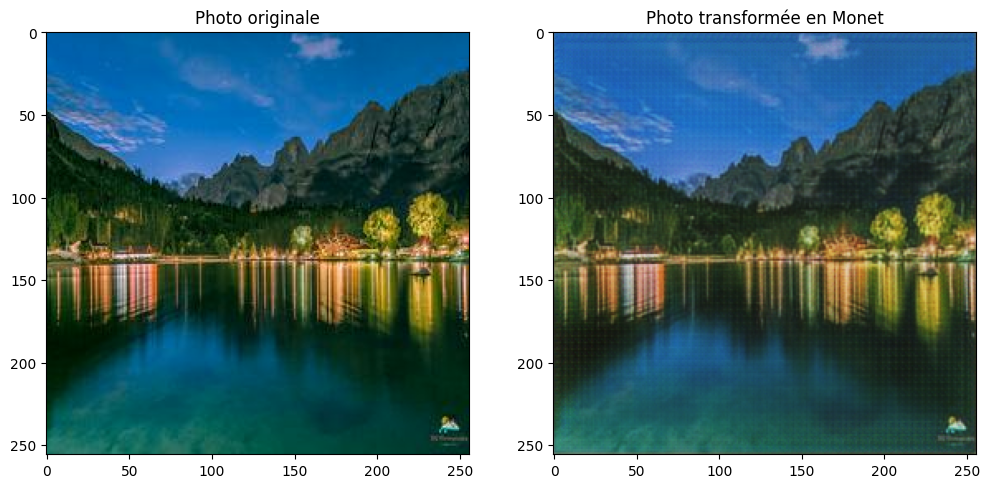

In [69]:
import matplotlib.pyplot as plt

# Charger une photo de l'ensemble photo
sample_photo = next(iter(photo_ds))

# Générer une peinture Monet à partir de cette photo
generated_monet = monet_generator(sample_photo, training=False)

# Afficher les résultats
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Photo originale")
plt.imshow((sample_photo[0] + 1) / 2)  # Dénormalisation
plt.subplot(1, 2, 2)
plt.title("Photo transformée en Monet")
plt.imshow((generated_monet[0] + 1) / 2)  # Dénormalisation
plt.show()


La vidéo est sauvegardée sous /content/transformation.mp4


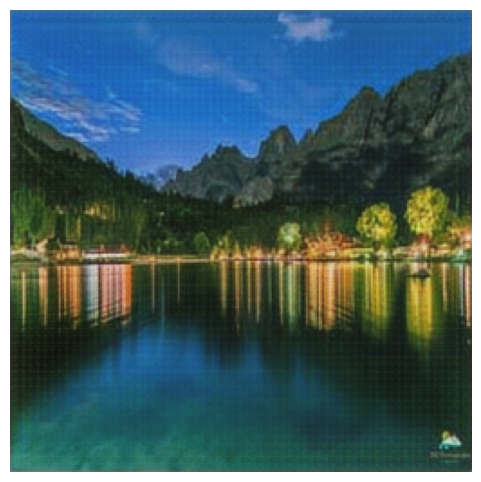

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter

# Fonction pour interpoler entre l'image réelle et l'image artistique
def interpolate_images(real_image, generated_image, steps=30):
    """Interpole entre deux images sur un nombre donné d'étapes."""
    interpolated_images = []
    for alpha in np.linspace(0, 1, steps):
        blended_image = (1 - alpha) * real_image + alpha * generated_image
        interpolated_images.append(blended_image)
    return interpolated_images

# Charger une image réelle et générer son style artistique
sample_photo = next(iter(photo_ds))  # Charger une photo du dataset
generated_monet = monet_generator(sample_photo, training=False)  # Générer l'image artistique

# Dénormaliser les images pour les afficher
sample_photo = (sample_photo[0].numpy() + 1) / 2  # Dénormalisation pour affichage
generated_monet = (generated_monet[0].numpy() + 1) / 2

# Interpoler les images
steps = 30  # Nombre d'étapes pour l'animation
interpolated_images = interpolate_images(sample_photo, generated_monet, steps=steps)

# Créer l'animation
fig, ax = plt.subplots(figsize=(6, 6))
ax.axis('off')  # Masquer les axes
img_display = ax.imshow(interpolated_images[0])  # Afficher la première image

def update(frame):
    """Met à jour l'image affichée."""
    img_display.set_array(interpolated_images[frame])
    return [img_display]

# Créer l'animation avec Matplotlib
ani = FuncAnimation(fig, update, frames=steps, interval=100, blit=True)

# Sauvegarder en vidéo MP4
video_path = "/content/transformation.mp4"
writer = FFMpegWriter(fps=10, metadata=dict(artist='Me'), bitrate=1800)
ani.save(video_path, writer=writer)

print(f"La vidéo est sauvegardée sous {video_path}")


In [57]:
!ls -l /content


total 110120
drwx------ 6 root root     4096 Jan 12 21:46 drive
-rw-r--r-- 1 root root 11097648 Jan 12 23:06 monet_discriminator.h5
-rw-r--r-- 1 root root 43635448 Jan 12 23:06 monet_generator.h5
-rw-r--r-- 1 root root 11097648 Jan 12 23:06 photo_discriminator.h5
-rw-r--r-- 1 root root 43635376 Jan 12 23:06 photo_generator.h5
drwxr-xr-x 1 root root     4096 Jan  9 14:24 sample_data
-rw-r--r-- 1 root root  3266727 Jan 12 23:39 transformation.gif


In [61]:
from google.colab import files

# Téléchargement du fichier GIF
files.download('/content/transformation.mp4')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>